🟦 1. Introduction

This EDA analyzes real estate data to identify pricing patterns and detect undervalued micro-markets using price per square foot and location-based insights.

🟦 2. Load Data

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../data/processed/cleaned_data.csv")
df.head()


,listing_id,internal_id,category,listing_type,detail_url,property_type,offering_type,completion_status,title,price_egp,...,agent_is_super,agent_languages,broker_id,broker_name,broker_email,broker_phone,contact_phone,contact_whatsapp,contact_email,scraped_at
0,F7QB31CGWE509V2W7DF2GARB2C,56009081.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/duple...,Duplex,Residential for Sale,completed,Garden Villa - Lake View Boutique - Prime Loca...,24500000.0,...,False,NaN,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.012018e+11,2.022126e+10,pierre.Osama@spade-consultancy.com,2026-03-04T14:20:33.281007
1,K1JC3D6N57ED52N3VX1QQKHHXG,56247925.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,off_plan,For Sale: Finished Apartment+ ACs in Village West,5145000.0,...,False,NaN,492.0,Abrag Real Estate,snawara71@gmail.com,2.010012e+11,2.010072e+11,2.022126e+10,ranoushamer901@gmail.com,2026-03-04T14:20:33.281007
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,56253883.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,UnderMarket Price for Apt. 250 RTM PrimeLocation,10800000.0,...,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007
3,PPH0852SAB266X6GSVATJP4F0M,56250852.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,lowest price 2bds fullyfurnished @ lake view,10500000.0,...,False,English | Arabic,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.010701e+11,2.022126e+10,ebrahim.hossam@spade-consultancy.com,2026-03-04T14:20:33.281007
4,QCSA4TNDEBBV7BNY8ANST3TB50,55995764.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/villa...,Villa,Residential for Sale,completed,Exclusive Type M with Lowest Price RTM in PNC,19500000.0,...,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007


🟦 3. Data Overview



The dataset contains multiple numerical and categorical features related to property pricing, area, and location.


In [3]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
df.head()

,listing_id,internal_id,category,listing_type,detail_url,property_type,offering_type,completion_status,title,price_egp,...,agent_is_super,agent_languages,broker_id,broker_name,broker_email,broker_phone,contact_phone,contact_whatsapp,contact_email,scraped_at
0,F7QB31CGWE509V2W7DF2GARB2C,56009081.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/duple...,Duplex,Residential for Sale,completed,Garden Villa - Lake View Boutique - Prime Loca...,24500000.0,...,False,NaN,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.012018e+11,2.022126e+10,pierre.Osama@spade-consultancy.com,2026-03-04T14:20:33.281007
1,K1JC3D6N57ED52N3VX1QQKHHXG,56247925.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,off_plan,For Sale: Finished Apartment+ ACs in Village West,5145000.0,...,False,NaN,492.0,Abrag Real Estate,snawara71@gmail.com,2.010012e+11,2.010072e+11,2.022126e+10,ranoushamer901@gmail.com,2026-03-04T14:20:33.281007
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,56253883.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,UnderMarket Price for Apt. 250 RTM PrimeLocation,10800000.0,...,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007
3,PPH0852SAB266X6GSVATJP4F0M,56250852.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,lowest price 2bds fullyfurnished @ lake view,10500000.0,...,False,English | Arabic,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.010701e+11,2.022126e+10,ebrahim.hossam@spade-consultancy.com,2026-03-04T14:20:33.281007
4,QCSA4TNDEBBV7BNY8ANST3TB50,55995764.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/villa...,Villa,Residential for Sale,completed,Exclusive Type M with Lowest Price RTM in PNC,19500000.0,...,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007


In [4]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 39713 entries, 0 to 39712
Data columns (total 53 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listing_id           39713 non-null  str    
 1   internal_id          39713 non-null  float64
 2   category             39713 non-null  str    
 3   listing_type         39713 non-null  str    
 4   detail_url           39713 non-null  str    
 5   property_type        39713 non-null  str    
 6   offering_type        39713 non-null  str    
 7   completion_status    39713 non-null  str    
 8   title                39713 non-null  str    
 9   price_egp            39713 non-null  float64
 10  price_period         39713 non-null  str    
 11  price_currency       39713 non-null  str    
 12  location_full        39713 non-null  str    
 13  city                 39713 non-null  str    
 14  town                 39713 non-null  str    
 15  district             39713 non-null  str    
 1

,internal_id,price_egp,lat,lon,area_value,images_count,rera,agent_id,broker_id,broker_phone,contact_phone,contact_whatsapp
count,3.971300e+04,3.971300e+04,39713.000000,39713.000000,39713.000000,39713.000000,0.0,39713.000000,39713.000000,3.971300e+04,3.971300e+04,3.971300e+04
mean,4.537974e+07,7.989093e+06,29.976420,31.318197,218.484149,12.275678,NaN,53288.206330,4144.914486,1.517696e+11,3.031820e+14,6.318644e+10
std,1.880482e+07,2.449255e+07,0.602524,0.857342,781.814044,4.823324,NaN,17909.158476,10005.031788,8.621367e+10,6.037840e+16,7.697952e+10
min,2.908155e+06,1.300000e+03,25.069366,25.476135,1.000000,0.000000,NaN,5500.000000,55.000000,1.000009e+09,2.010000e+11,2.022126e+10
25%,5.245429e+07,6.500000e+04,30.001993,31.015570,130.000000,10.000000,NaN,42365.000000,1614.000000,2.010001e+11,2.010330e+11,2.022126e+10
50%,5.476102e+07,6.000000e+05,30.025003,31.497156,175.000000,11.000000,NaN,57459.000000,4208.000000,2.010267e+11,2.011022e+11,2.022126e+10
75%,5.575866e+07,9.115000e+06,30.061470,31.546247,245.000000,14.000000,NaN,68818.000000,5657.000000,2.011170e+11,2.011456e+11,2.022126e+10
max,5.649342e+07,1.000000e+09,31.497467,34.896572,96600.000000,30.000000,NaN,73845.000000,179957.000000,2.015582e+11,1.203228e+19,2.015598e+11


🟦 4. Missing Values Check

Missing values were minimal and handled during the cleaning phase.

In [5]:
df.isnull().sum()

listing_id                 0
internal_id                0
category                   0
listing_type               0
detail_url                 0
property_type              0
offering_type              0
completion_status          0
title                      0
price_egp                  0
price_period               0
price_currency             0
location_full              0
city                       0
town                       0
district                   0
subdistrict                0
lat                        0
lon                        0
bedrooms                   0
bathrooms                  0
area_value                 0
area_unit                  0
furnished                  1
listing_level              0
is_premium                 0
is_verified                0
is_featured                0
is_new_construction        0
is_direct_from_dev         0
is_exclusive               0
listed_date                0
images_count               0
has_view_360               0
video_url     

🟦 5. Price Distribution

    The distribution of property prices is analyzed to understand market spread  and             detect skewness or outliers.

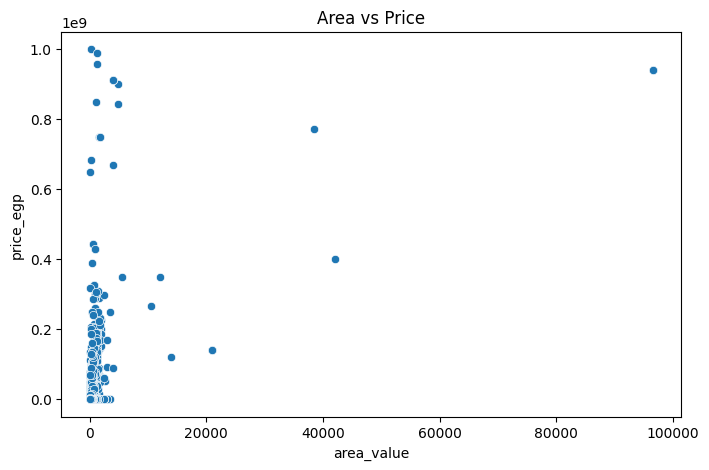

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='area_value', y='price_egp', data=df)
plt.title("Area vs Price")
plt.show()

🟦 7. Feature Engineering 

A new feature, price per square foot, is created to normalize property prices and enable fair comparison.

In [18]:
df['price_per_sqft'] = df['price_egp'] / df['area_value']

🟦 8. Price per Sqft Distribution

This metric helps identify pricing efficiency across properties.

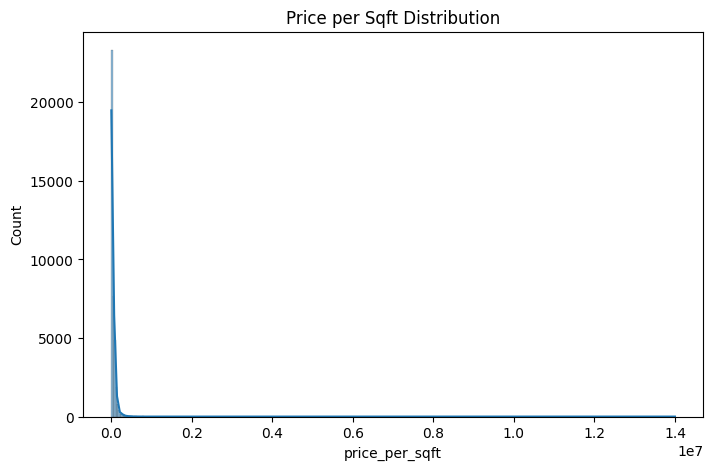

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['price_per_sqft'], kde=True)
plt.title("Price per Sqft Distribution")
plt.show()

🟦 9. Location Analysis 

Locations with lower average price per square foot are identified as potential undervalued micro-markets.

In [10]:
location_price = df.groupby('location_full')['price_per_sqft'].mean().sort_values()

location_price.head(10)   # Undervalued
location_price.tail(10)   # Expensive

location_full
Ahmed Basha St., Garden City, Cairo                                             4.554409e+05
Nadi Al Zamalek St., Mohandessin, Giza                                          4.622222e+05
Al Patio 5 East, El Patio, El Shorouk Compounds, Shorouk City, Cairo            5.235817e+05
Upville, Cairo Alexandria Desert Road, 6 October City, Giza                     6.976052e+05
La Rosa, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo    7.547240e+05
La Capitale, New Capital Compounds, New Capital City, Cairo                     1.300950e+06
Jefaira Quayside, Jefaira, Ras Al Hekma, North Coast                            1.538061e+06
Hilton Cairo Nile Maadi, Athar El Nabi, Hay Masr El Kadima, Cairo               2.510517e+06
Coronado Beach, Al Ain Al Sokhna, Suez                                          2.550000e+06
Ayla Jefaira, Jefaira, Ras Al Hekma, North Coast                                4.000000e+06
Name: price_per_sqft, dtype: float64

🟦 10. Listing Density

High listing counts indicate active markets with higher demand.

In [12]:
df['location_full'].value_counts().head(10)

location_full
Mivida, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo                 2433
Eastown, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo                1358
Lake View Residence, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo    1222
Villette, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo               1056
Privado, Madinaty, Cairo                                                                    1007
Hyde Park, New Cairo City, Cairo                                                             999
Cairo Festival City, North Investors Area, New Cairo City, Cairo                             859
Mountain View iCity, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo     635
El Rehab Extension, Al Rehab, New Cairo City, Cairo                                          624
Moon Residences, Fifth Square, The 5th Settlement, New Cairo City, Cairo                     534
Name: count, dty

🟦 11. Premium vs Non-Premium


Premium properties generally show higher price per square foot compared to non-premium listings.

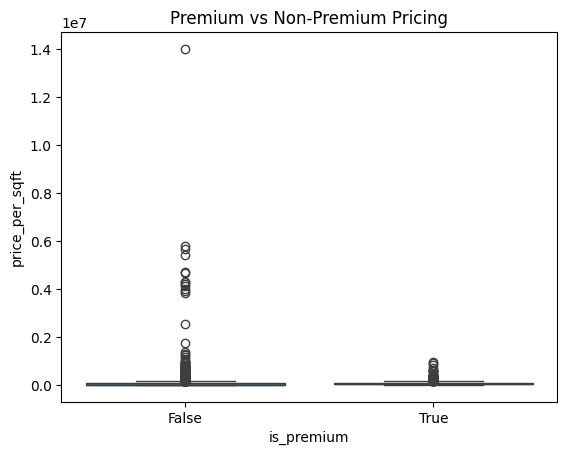

In [13]:
sns.boxplot(x='is_premium', y='price_per_sqft', data=df)
plt.title("Premium vs Non-Premium Pricing")
plt.show()

🟦 12. Correlation Analysis

Correlation analysis highlights relationships between key variables influencing property pricing.

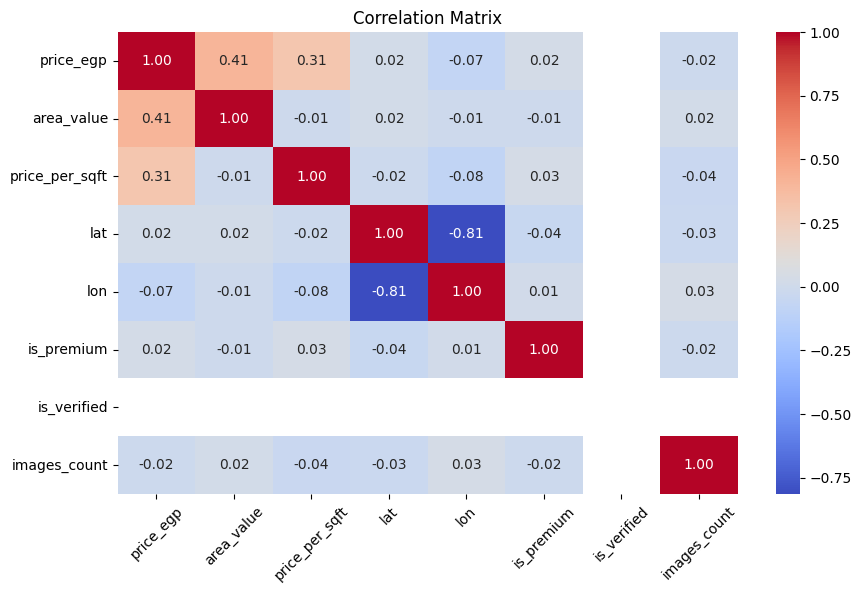

In [21]:
important_cols = [
    'price_egp',
    'area_value',
    'price_per_sqft',
    'lat',
    'lon',
    'is_premium',
    'is_verified',
    'images_count'
]


plt.figure(figsize=(10,6))
sns.heatmap(df[important_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.show()

🟦 13. Key Insights

* Property prices are right-skewed due to high-value listings.
* Area and price show a strong positive relationship.
* Price per square foot is the most important metric for valuation.
* Significant variation across locations indicates undervalued markets.
* Premium properties tend to have higher pricing.

🟦 14. Conclusion

The EDA reveals strong patterns in pricing and location, which will be used in further statistical and machine learning analysis to identify undervalued micro-markets.